In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
dataset = baseClasses.Data()

In [12]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 9, 21)) & (dataset.data.index < datetime.datetime(2024, 11, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [13]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
prm = systemClasses.System(dataset=dataset, name="PRM")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pp = systemClasses.System(dataset=dataset, name="PP")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:00<00:00, 13.92sensor/s]


ERROR: Channel (TE0120) not found


Initializing HAWAI Sensors: 100%|██████████| 24/24 [00:01<00:00, 14.91sensor/s]


In [14]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pp.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.96sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 92.95sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  7.86sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 6/6 [00:00<00:00, 109.75sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  8.24sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:00<00:00, 78.11sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  7.39sensor/s]
Calibrating PP Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 2/2 [00:00<00:00, 92.20sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00,  8.70sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 67.32sensor/s]


In [15]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

cryo = systemClasses.System(dataset=dataset, name="CRYO")
ce = systemClasses.System(dataset=dataset, name="CE")
ambient = systemClasses.System(dataset=dataset, name="AMBIENT")
hv = systemClasses.System(dataset=dataset, name="HV")

Initializing CRYO Sensors:   0%|          | 0/16 [00:00<?, ?sensor/s]

Initializing HV Sensors: 100%|██████████| 2/2 [00:00<00:00, 13.13sensor/s]


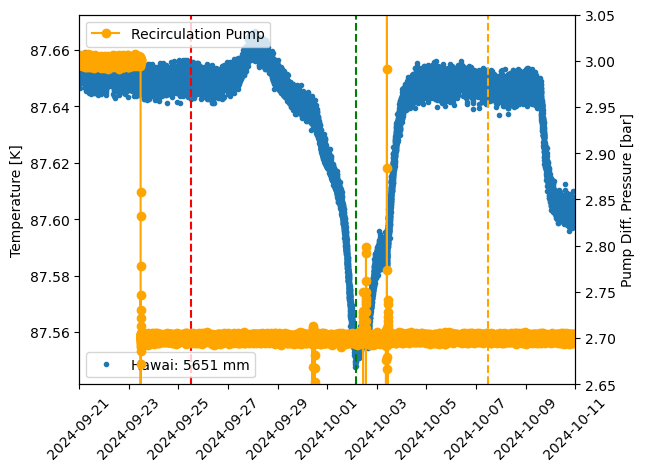

In [46]:
fig, axes = plt.subplots(1,1)
axes.plot(hawai.sensors[40014].data, ".", label="Hawai: 5651 mm")
# axes.set_ylim(87.25, 87.30)
axes.set_xlim(datetime.datetime(2024, 9, 21), datetime.datetime(2024, 10, 11))
axes.axvline(datetime.datetime(2024, 9, 25, 12), color="red", linestyle="--")
axes.axvline(datetime.datetime(2024, 10, 2, 4), color="green", linestyle="--")
axes.axvline(datetime.datetime(2024, 10, 7, 12), color="orange", linestyle="--")
axes.legend(loc="lower left")
axes.set_ylabel("Temperature [K]")
plt.xticks(rotation=45)
axes2 = axes.twinx()
# axes2.plot(ce.sensors[1018].data, "o", color="red")
# axes2.plot(ce.sensors[1023].data, "o", color="green")
# axes2.plot(mux3.data, color="tab:orange")
# axes2.set_ylim(1.0006, 1.0008)
# axes2.plot(ce.sensors[1017].data, "-o", color="red", label="CE APA1")
axes2.plot(cryo.sensors[1048].data, "-o", color="orange", label="Recirculation Pump")
axes2.set_ylabel("Pump Diff. Pressure [bar]")
axes2.set_ylim(2.65, 3.05)
# axes2.plot(ce.sensors[1033].data, "-o", color="orange")
# axes2.plot(cryo.sensors[1048].data, color="green")
axes2.legend(loc="upper left")

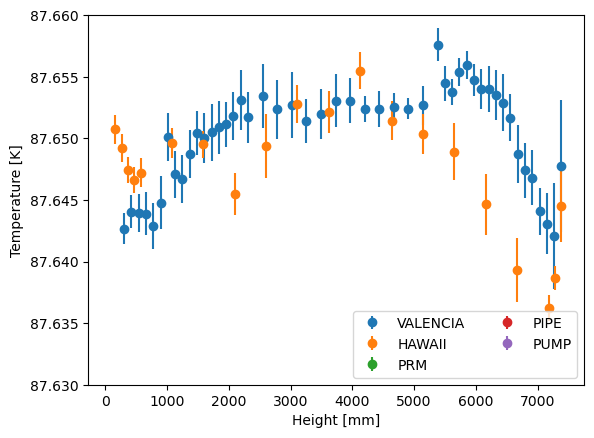

In [28]:
def plot_all_profiles(tini, tend, ylim1, ylim2):
    tgrad.makeProfiles(tini=tini, tend=tend)
    hawai.makeProfiles(tini=tini, tend=tend)
    pipe.makeProfiles(tini=tini, tend=tend)
    prm.makeProfiles(tini=tini, tend=tend)
    pp.makeProfiles(tini=tini, tend=tend)
    plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
    plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII")
    plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values + 0.005, yerr=prm.profiles["err"].values, fmt='o', label="PRM")
    plt.errorbar(pipe.profiles["Y"].values, pipe.profiles["temp"].values + 0.005, yerr=pipe.profiles["err"].values, fmt='o', label="PIPE")
    plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values + 0.005, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
    plt.ylim(ylim1,ylim2)
    plt.legend(ncol=2);
    plt.xlabel("Height [mm]")
    plt.ylabel("Temperature [K]")

plot_all_profiles(datetime.datetime(2024, 9, 25, 12), datetime.datetime(2024, 9, 25, 12, 30), 87.63, 87.66)

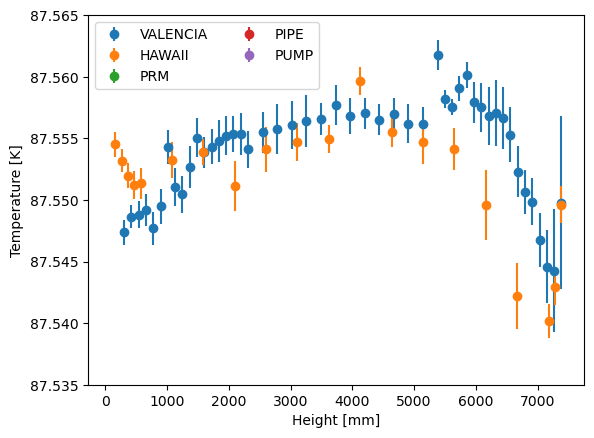

In [45]:
plot_all_profiles(datetime.datetime(2024, 10, 2, 4), datetime.datetime(2024, 10, 2, 4, 30), 87.535, 87.565)

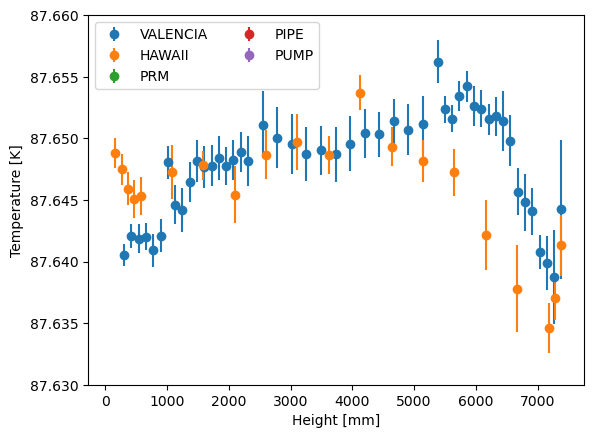

In [47]:
plot_all_profiles(datetime.datetime(2024, 10, 7, 12), datetime.datetime(2024, 10, 7, 12, 30), 87.63, 87.66)

In [ ]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import datetime

tini = datetime.datetime(2024, 9, 25, 12)
tend = datetime.datetime(2024, 10, 24, 0)
observables = {}

total_time = (tend - tini).total_seconds()  # Total time span in seconds
time_step = 30 * 60  # 30 minutes in seconds
total_steps = int(total_time / time_step)  # Adjusted number of iterations

with tqdm(total=total_steps, desc="Processing Profiles") as pbar:
    while tini < tend:
        p = tgrad.makeProfiles(tini=tini, tend=tini + datetime.timedelta(minutes=30))
        try:
            bot = p.profiles.loc[(p.profiles["Y"] < 1000)]
            mid = p.profiles.loc[(p.profiles["Y"] > 2500) & (p.profiles["Y"] < 5200)]
            top = p.profiles.loc[(p.profiles["Y"] > 5500) & (p.profiles["Y"] < 6500)]

            gradbm = bot["temp"].mean() - mid["temp"].mean()
            gradmt = mid["temp"].mean() - top["temp"].mean()
            gradbt = bot["temp"].mean() - top["temp"].mean()

            gradbm_err = np.sqrt(bot["temp"].std()**2 + mid["temp"].std()**2)
            gradmt_err = np.sqrt(mid["temp"].std()**2 + top["temp"].std()**2)
            gradbt_err = np.sqrt(bot["temp"].std()**2 + top["temp"].std()**2)

            observables[tini] = {
                "gradbm": gradbm, "gradmt": gradmt, "gradbt": gradbt,
                "gradbm_err": gradbm_err, "gradmt_err": gradmt_err, "gradbt_err": gradbt_err
            }

            tini += datetime.timedelta(minutes=30)
            pbar.update(1)  # Update progress bar by 1 step
        except:
            pbar.update(1)  # Update progress bar by 1 step
            tini += datetime.timedelta(minutes=30)

observables = pd.DataFrame.from_dict(observables, orient="index")


Processing Profiles: 100%|██████████| 1368/1368 [03:24<00:00,  6.70it/s]


In [76]:
print(observables)

                       gradbm    gradmt    gradbt  gradbm_err  gradmt_err  \
2024-09-25 12:00:00 -0.008833 -0.001741 -0.010574    0.000950    0.001144   
2024-09-25 12:30:00 -0.008983 -0.001413 -0.010396    0.001072    0.001311   
2024-09-25 13:00:00 -0.008816 -0.001613 -0.010429    0.000948    0.001234   
2024-09-25 13:30:00 -0.008834 -0.001857 -0.010691    0.001115    0.001240   
2024-09-25 14:00:00 -0.009008 -0.002131 -0.011139    0.001316    0.001474   
...                       ...       ...       ...         ...         ...   
2024-10-10 21:30:00 -0.009045 -0.001125 -0.010170    0.000840    0.001219   
2024-10-10 22:00:00 -0.007668 -0.002847 -0.010515    0.000875    0.001001   
2024-10-10 22:30:00 -0.008508 -0.002097 -0.010606    0.001067    0.001145   
2024-10-10 23:00:00 -0.007760 -0.002576 -0.010336    0.000906    0.001107   
2024-10-10 23:30:00 -0.007963 -0.002457 -0.010420    0.001053    0.001262   

                     gradbt_err  
2024-09-25 12:00:00    0.001286  
2024-09

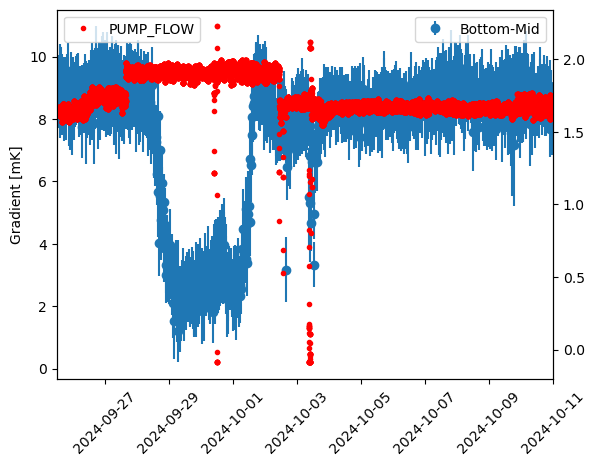

In [110]:
cryoId = 1049
fig, axes = plt.subplots(1,1)
axes.errorbar(observables.index.values, -1e3*observables["gradbm"].values, yerr=1e3*observables["gradbm_err"].values, fmt="o", label="Bottom-Mid")
#plt.errorbar(observables.index.values, observables["gradmt"].values, yerr=observables["gradmt_err"].values, fmt=".", label="Mid-Top")
#plt.errorbar(observables.index.values, -observables["gradbt"].values, yerr=observables["gradbt_err"].values, fmt=".", label="Bottom-Top")
axes.set_ylabel("Gradient [mK]")
plt.xticks(rotation=45)
axes.legend()
axes2 = axes.twinx()
axes2.plot(cryo.sensors[cryoId].data, ".", color="red", label=fr"{cryo.sensors[cryoId].name}")
axes2.set_xlim(datetime.datetime(2024, 9, 25, 12), datetime.datetime(2024, 10, 11))
axes2.legend(loc="upper left")

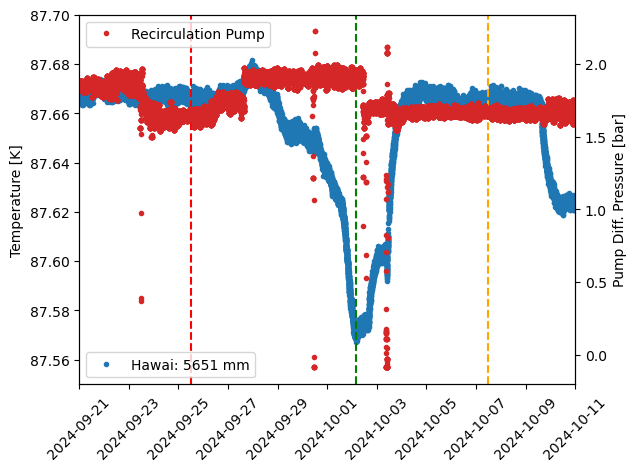

In [120]:
fig, axes = plt.subplots(1,1)
axes.plot(pipe.sensors[39671].data, ".", label="Hawai: 5651 mm")
axes.set_ylim(87.55, 87.7)
axes.set_xlim(datetime.datetime(2024, 9, 21), datetime.datetime(2024, 10, 11))
axes.axvline(datetime.datetime(2024, 9, 25, 12), color="red", linestyle="--")
axes.axvline(datetime.datetime(2024, 10, 2, 4), color="green", linestyle="--")
axes.axvline(datetime.datetime(2024, 10, 7, 12), color="orange", linestyle="--")
axes.legend(loc="lower left")
axes.set_ylabel("Temperature [K]")
plt.xticks(rotation=45)
axes2 = axes.twinx()
# axes2.plot(ce.sensors[1018].data, "o", color="red")
# axes2.plot(ce.sensors[1023].data, "o", color="green")
# axes2.plot(mux3.data, color="tab:orange")
# axes2.set_ylim(1.0006, 1.0008)
# axes2.plot(ce.sensors[1017].data, "-o", color="red", label="CE APA1")
axes2.plot(cryo.sensors[1049].data, ".", color="tab:red", label="Recirculation Pump")
axes2.set_ylabel("Pump Diff. Pressure [bar]")
# axes2.set_ylim(2.65, 3.05)
# axes2.plot(ce.sensors[1033].data, "-o", color="orange")
# axes2.plot(cryo.sensors[1048].data, color="green")
axes2.legend(loc="upper left")

In [121]:
dataset = baseClasses.Data()

In [122]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 12, 15)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [123]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [02:18<00:00,  2.89s/sensor]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:03<00:00, 12.34sensor/s]


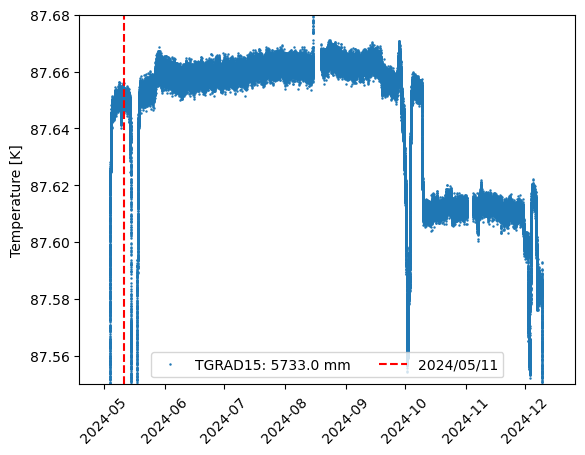

In [ ]:
fig, axes = plt.subplots(1,1)
sensor_id = 40525
deltat = datetime.timedelta(minutes=15)
t1 = datetime.datetime(2024, 5, 11, 12)
axes.plot(tgrad.sensors[sensor_id].data, ".", markersize=1.5, label=f"{tgrad.sensors[sensor_id].name}: {tgrad.sensors[sensor_id].Y} mm")
axes.axvline(t1, color="red", linestyle="--", label=f"{t1.strftime('%Y/%m/%d')}")
# axes.set_ylim(87.25, 87.30)
# axes.set_xlim(datetime.datetime(2024, 9, 21), datetime.datetime(2024, 10, 11))
# axes.axvline(datetime.datetime(2024, 9, 25, 12), color="red", linestyle="--")
# axes.axvline(datetime.datetime(2024, 10, 2, 4), color="green", linestyle="--")
# axes.axvline(datetime.datetime(2024, 10, 7, 12), color="orange", linestyle="--")
axes.set_ylim(87.55, 87.68)
axes.legend(loc="lower center", ncol=3)
axes.set_ylabel("Temperature [K]")
plt.xticks(rotation=45);